In [11]:
#call vegbank api:
# api key is $VEGBANK_API_KEY
# https://nceas.github.io/vegbank2/api/

# use status = "current", limit=500,000, create_parquet=True
# !curl -X GET "https://api.vegbank.org/plot-observations" -H "Authorization: Bearer $VEGBANK_API_KEY" > vegbank_plot_observations.json
!curl -X GET "https://api.vegbank.org/plot-observations?status=current&limit=500000&create_parquet=true" -H "Authorization: Bearer $VEGBANK_API_KEY" > vegbank_plot_observations.parquet

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16.0M  100 16.0M    0     0   196k      0  0:01:23  0:01:23 --:--:-- 3792k --:--:--  0:01:05 --:--:--     0


plot level data contains vegetation community records: `top_classifications` -> comm_code / comm_name with descriptions in vegetation community concepts table


groundcover

lots of plot -level variables

also contains::

`top_taxon_observations` :
```json
"plant_name": "Acer rubrum",
"sr_code": "sr.1",
"stratum_name": "herb",
"cover": 0.7
```

disturbances:
```json
"disturbances": [
{
"type": "Wind event",
"comment": "Hurricane blowdown",
"intensity": "Low",
"age": 10,
"extent": 5
}
],
```


soils

doesn't contain stem counts; can get from separate table:

defaults to 5 most common taxa

stem counts https://nceas.github.io/vegbank2/api/#tag/Stem-counts/operation/get-sc-by-tm

table of observed taxa:
https://nceas.github.io/vegbank2/api/#tag/Taxon-observations/operation/get-to

vegetation communitites?!
https://nceas.github.io/vegbank2/api/#tag/Community-concepts/operation/get-cc-by-id

In [30]:
import json
import polars as pl
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as ctx

In [32]:
plots = pl.read_parquet("vegbank_plot_observations.parquet")
plots.head(2)

ob_code,author_obs_code,pl_code,author_plot_code,pj_code,project_name,rf_code,rf_label,has_observation_synonym,replaced_by_ob_code,parent_pl_code,location_accuracy,confidentiality_status,latitude,longitude,author_e,author_n,author_zone,author_datum,author_location,location_narrative,azimuth,dsg_poly,shape,area,stand_size,placement_method,permanence,layout_narrative,elevation,elevation_accuracy,elevation_range,slope_aspect,min_slope_aspect,max_slope_aspect,slope_gradient,min_slope_gradient,…,hydrologic_regime,soil_moisture_regime,soil_drainage,water_salinity,water_depth,shore_distance,soil_depth,organic_depth,st_code,soil_taxon_src,percent_bed_rock,percent_rock_gravel,percent_wood,percent_litter,percent_bare_soil,percent_water,percent_other,name_other,tree_ht,shrub_ht,field_ht,nonvascular_ht,submerged_ht,tree_cover,shrub_cover,field_cover,nonvascular_cover,floating_cover,submerged_cover,dominant_stratum,growthform_1_type,growthform_2_type,growthform_3_type,growthform_1_cover,growthform_2_cover,growthform_3_cover,total_cover
str,str,str,str,str,str,str,str,bool,null,null,f64,i64,f64,f64,str,str,str,str,str,str,f64,str,str,f64,str,str,bool,str,f64,f64,f64,f64,f64,f64,f64,f64,…,str,str,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64
"""ob.2948""","""ACAD.143""","""pl.3004""","""ACAD.143""","""pj.340""","""Acadia National Park""",null,null,false,null,null,null,0,44.346509,-68.22934,"""561385""","""4910423""","""19""",null,"""ACAD -- Acadia - S ridge Cadil…",null,null,null,"""Rectangular""",null,null,null,false,null,416.0,null,null,282.0,null,null,12.0,null,…,"""Upland""",null,"""moderately well drained""",null,null,null,null,null,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ob.2949""","""ACAD.144""","""pl.3005""","""ACAD.144""","""pj.340""","""Acadia National Park""",null,null,false,null,null,null,0,44.340021,-68.227054,"""561574""","""4909704""","""19""",null,"""ACAD -- Acadia - S Ridge Trail…",null,null,null,"""Rectangular""",null,null,null,false,null,300.0,null,null,0.0,null,null,0.0,null,…,"""Seasonally flooded""",null,"""very poorly drained""",null,null,null,null,null,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [33]:
plots_filtered = plots.filter(pl.col("location_accuracy") < 30)
len(plots_filtered), f"{len(plots_filtered)/len(plots)*100:.2f}%"

(31327, '22.56%')

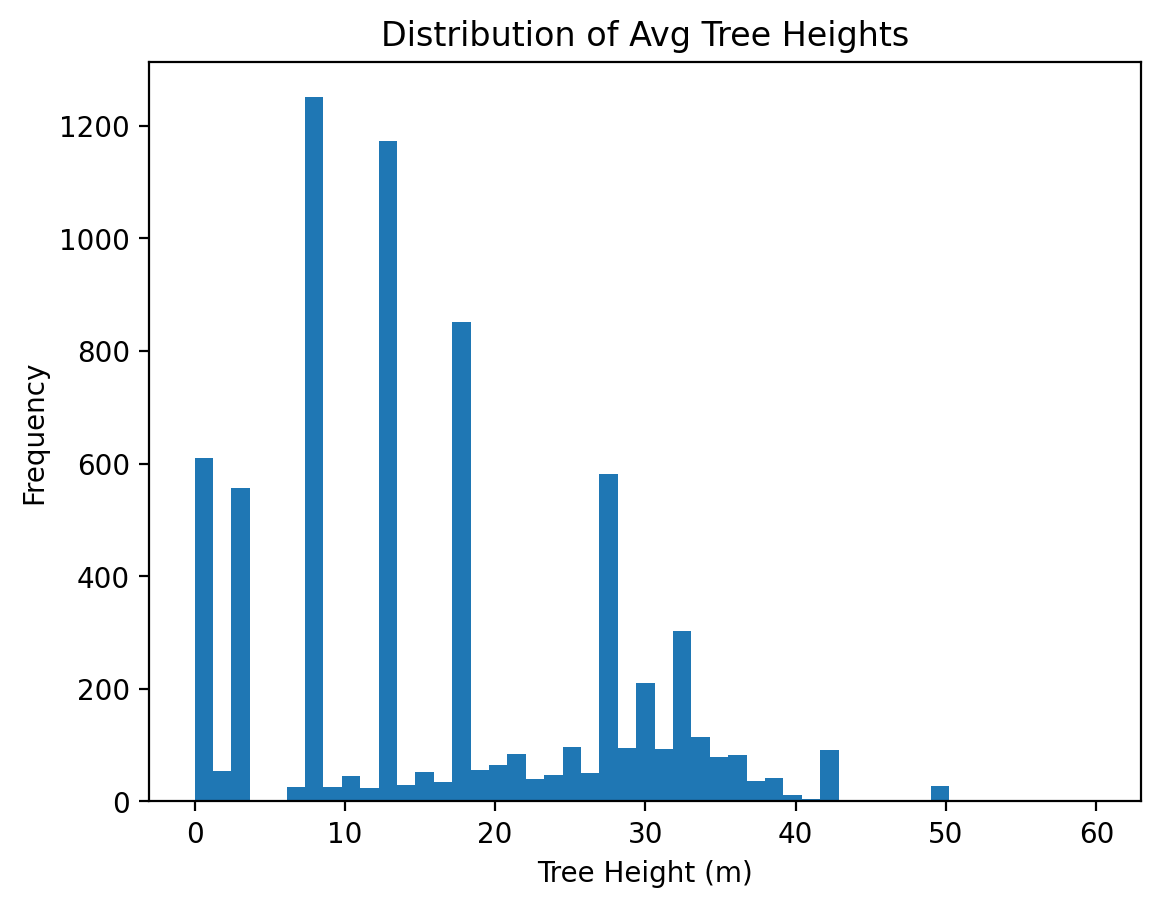

In [42]:
_ = plt.hist(plots_filtered["tree_ht"], bins=np.linspace(0, 60, 50))
plt.xlabel("Tree Height (m)")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Tree Heights")
plt.show()

In [43]:
plots_filtered.columns

['ob_code',
 'author_obs_code',
 'pl_code',
 'author_plot_code',
 'pj_code',
 'project_name',
 'rf_code',
 'rf_label',
 'has_observation_synonym',
 'replaced_by_ob_code',
 'parent_pl_code',
 'location_accuracy',
 'confidentiality_status',
 'latitude',
 'longitude',
 'author_e',
 'author_n',
 'author_zone',
 'author_datum',
 'author_location',
 'location_narrative',
 'azimuth',
 'dsg_poly',
 'shape',
 'area',
 'stand_size',
 'placement_method',
 'permanence',
 'layout_narrative',
 'elevation',
 'elevation_accuracy',
 'elevation_range',
 'slope_aspect',
 'min_slope_aspect',
 'max_slope_aspect',
 'slope_gradient',
 'min_slope_gradient',
 'max_slope_gradient',
 'topo_position',
 'landform',
 'surficial_deposits',
 'rock_type',
 'country',
 'state_province',
 'previous_ob_code',
 'year',
 'obs_start_date',
 'obs_end_date',
 'date_accuracy',
 'date_entered',
 'cm_code',
 'cover_method_name',
 'cover_dispersion',
 'auto_taxon_cover',
 'sm_code',
 'stratum_method_name',
 'stratum_method_descri

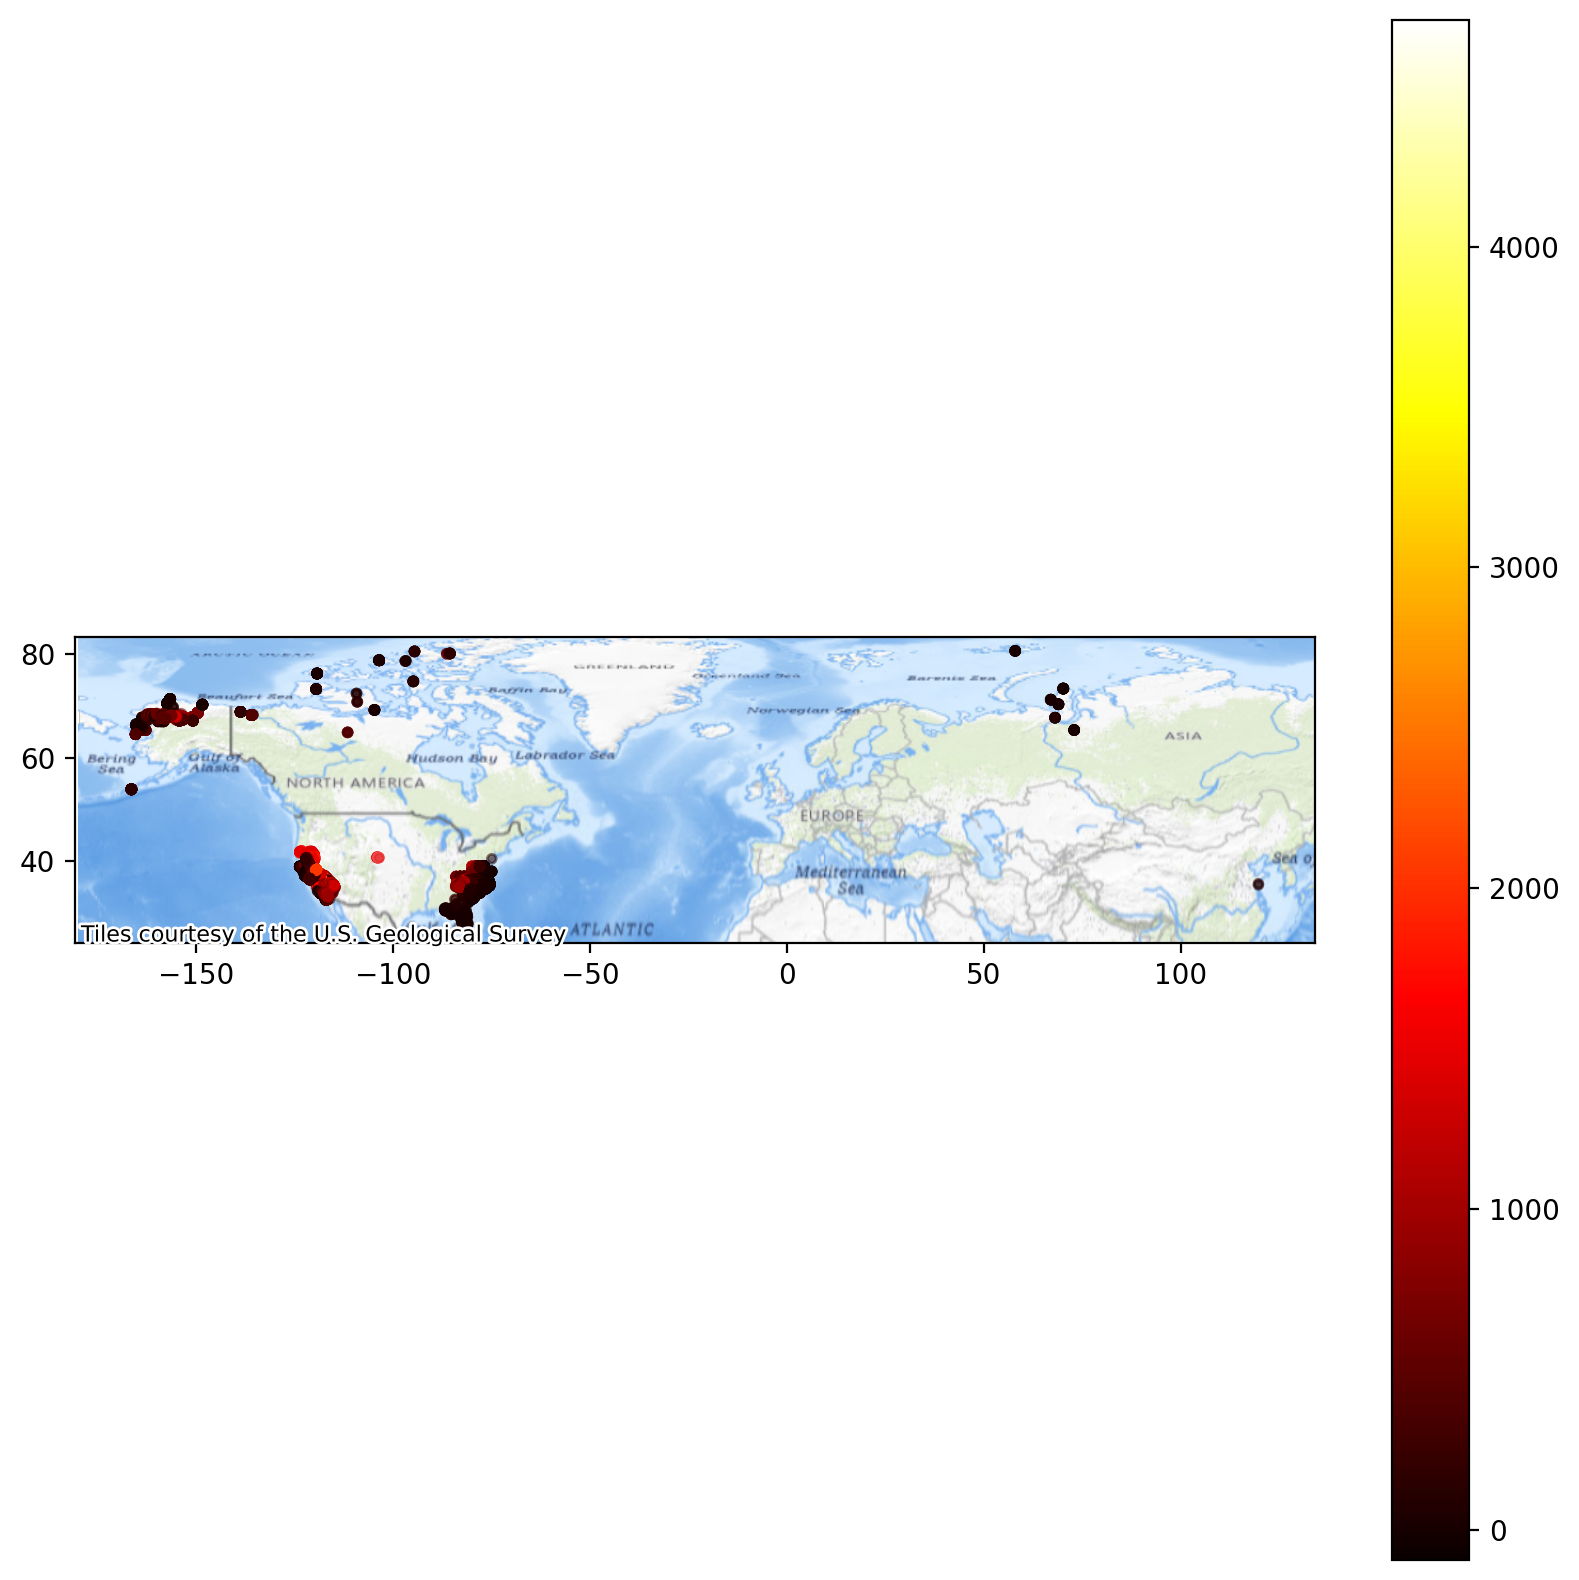

In [46]:
gdf = gpd.GeoDataFrame(
    plots_filtered.to_pandas(),
    geometry=gpd.points_from_xy(
        plots_filtered["longitude"], plots_filtered["latitude"]
    ),
    crs="EPSG:4326",
)
dpl_map = gdf.plot(
    figsize=(10, 10),
    alpha=0.5,
    edgecolor=None,
    column="elevation",
    legend=True,
    cmap="hot",
    markersize=10,
)
ctx.add_basemap(dpl_map, crs=gdf.crs.to_string(), source=ctx.providers.USGS.USTopo)

In [56]:
plots["location_accuracy"].is_null().mean()

0.6888698420472634

In [ ]:
gdf = gpd.GeoDataFrame(
    plots.to_pandas(),
    geometry=gpd.points_from_xy(plots["longitude"], plots["latitude"]),
    crs="EPSG:4326",
)
geo_filtered = gdf.cx[-125:-65, 25:50]
geo_filtered["elevation"] = np.clip(geo_filtered["elevation"], 0, 4000)
dpl_map = geo_filtered.plot(
    figsize=(10, 10),
    alpha=0.5,
    edgecolor=None,
    column="elevation",
    legend=True,
    cmap="hot",
    markersize=10,
)
ctx.add_basemap(dpl_map, crs=gdf.crs.to_string(), source=ctx.providers.USGS.USTopo)